In [1]:
import numpy as np
import pandas as pd
import mne
from pathlib import Path
PROJECT_ROOT = Path("/Users/daniel/PhD/spectral-comparison/code")

def load_spatial_coordinates(file_path: str) -> dict:
    df_channels = pd.read_csv(file_path, quotechar="'")
    channel_names = df_channels['Channel name'].str.strip().tolist()
    
    coordinates_mm = df_channels[['x', 'y', 'z']].to_numpy()
    coordinates_m = coordinates_mm / 1000.0
    
    return dict(zip(channel_names, coordinates_m))

def plot_electrode_montage(ch_pos: dict, sampling_rate_hz: float = 1000.0):
    montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame='mni_tal')
    
    channel_names = list(ch_pos.keys())
    info = mne.create_info(ch_names=channel_names, sfreq=sampling_rate_hz, ch_types='seeg')
    info.set_montage(montage)
    
    subjects_dir = mne.datasets.sample.data_path() / 'subjects'
    mne.datasets.fetch_fsaverage(subjects_dir=subjects_dir)
    
    fig = mne.viz.plot_alignment(
        info=info,
        subject='fsaverage',
        subjects_dir=subjects_dir,
        surfaces='pial',
        coord_frame='mni_tal'
    )
    
    mne.viz.set_3d_view(figure=fig, azimuth=200, elevation=70)
    return fig


In [2]:
import pandas as pd
from nilearn import plotting

df = pd.read_csv(f"{PROJECT_ROOT}/data/Frauscher2018/ChannelInformation.csv")

for col in ["Channel name", "Electrode type", "Hemisphere"]:
    df[col] = df[col].astype(str).str.strip("'")

coords = df[["x", "y", "z"]].to_numpy()

view = plotting.view_markers(
    marker_coords=coords,
    marker_size=3,
    marker_labels=df["Channel name"].tolist(),
)
view.open_in_browser()

<Figure size 800x600 with 0 Axes>

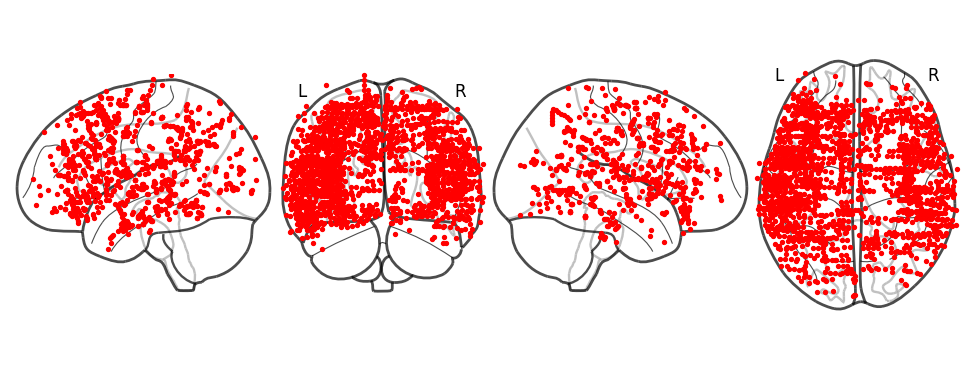

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting

df = pd.read_csv(f"{PROJECT_ROOT}/data/Frauscher2018/ChannelInformation.csv")

for col in ["Electrode type", "Hemisphere"]:
    df[col] = df[col].astype(str).str.strip().str.strip("'").str.upper()

# Reconstruct signed x-coordinate from hemisphere
df["x_signed"] = df["x"].abs()
df.loc[df["Hemisphere"] == "L", "x_signed"] *= -1
df.loc[df["Hemisphere"] == "R", "x_signed"] *= +1

coords = df[["x_signed", "y", "z"]].to_numpy()

fig = plt.figure(figsize=(8, 6))
display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display.add_markers(coords, marker_size=8)
plotting.show()

Saved PNG to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_glass_brain.png
Saved PDF to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_glass_brain.pdf


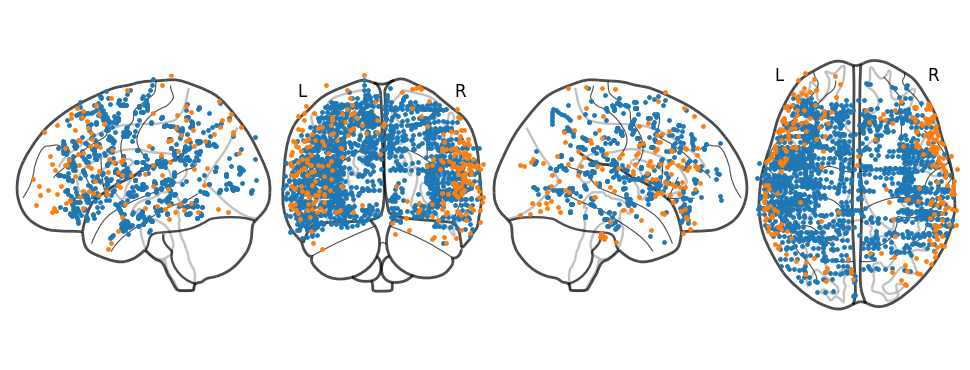

In [13]:
import pandas as pd
from pathlib import Path
from nilearn import plotting

df = pd.read_csv(f"{PROJECT_ROOT}/data/Frauscher2018/ChannelInformation.csv")

for col in ["Electrode type", "Hemisphere"]:
    df[col] = df[col].astype(str).str.strip().str.strip("'").str.upper()

df["x_signed"] = df["x"].abs()
df.loc[df["Hemisphere"] == "L", "x_signed"] *= -1

seeg = df[df["Electrode type"].isin(["D", "M", "A"])]
grid = df[df["Electrode type"] == "G"]

coords_seeg = seeg[["x_signed", "y", "z"]].to_numpy()
coords_grid = grid[["x_signed", "y", "z"]].to_numpy()

output_dir = Path(f"{PROJECT_ROOT}/notebooks/figures/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display.add_markers(coords_seeg, marker_size=6, marker_color="tab:blue")
display.add_markers(coords_grid, marker_size=6, marker_color="tab:orange")

png_path = output_dir / "frauscher_glass_brain.png"
pdf_path = output_dir / "frauscher_glass_brain.pdf"

display.savefig(str(png_path), dpi=300)
display.savefig(str(pdf_path))

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

plotting.show()

                                          label          x          y  \
0          Superior and middle occipital gyri_l -35.071396 -77.866285   
1          Superior and middle occipital gyri_r  38.252817 -80.434666   
2  Inferior ocipital gyrus and occipital pole_l -38.126674 -80.314732   
3  Inferior ocipital gyrus and occipital pole_r  45.549254 -74.207853   
4                                      Cuneus_l  -3.298641 -82.723581   

           z  
0  25.680365  
1  21.695919  
2   3.256962  
3  -3.549357  
4  25.637476  
Saved PNG to: /Users/daniel/PhD/spectral-comparison/code/results/reference_centroids_glass_brain.png
Saved PDF to: /Users/daniel/PhD/spectral-comparison/code/results/reference_centroids_glass_brain.pdf


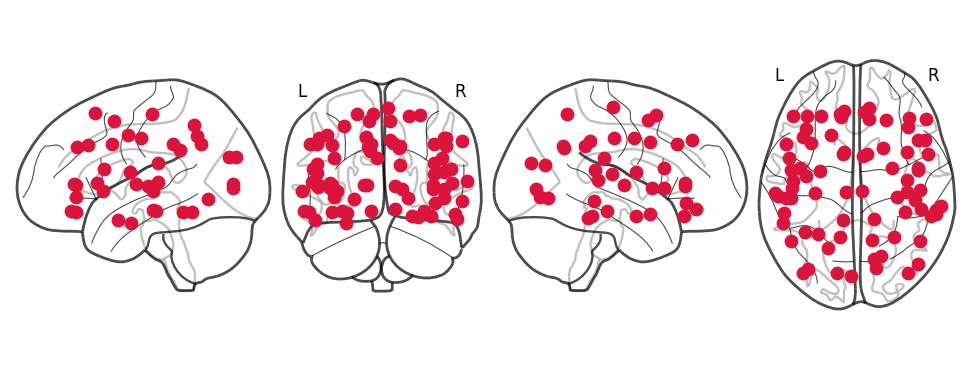

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.io import loadmat
from nilearn import plotting

PROJECT_ROOT = Path(PROJECT_ROOT)
mat_path = PROJECT_ROOT / "data" / "Mantini2018" / "seed_iEEG.mat"
output_dir = PROJECT_ROOT / "results"
output_dir.mkdir(parents=True, exist_ok=True)

mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
seed_info = mat["seed_info"]

rows = []
for item in np.ravel(seed_info):
    label = str(item.label).strip().strip("'")
    coord = np.asarray(item.coord_mni, dtype=float).ravel()
    rows.append(
        {
            "label": label,
            "x": coord[0],
            "y": coord[1],
            "z": coord[2],
        }
    )

centroids = pd.DataFrame(rows)

display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display.add_markers(
    centroids[["x", "y", "z"]].to_numpy(),
    marker_size=80,
    marker_color="crimson",
)

png_path = output_dir / "reference_centroids_glass_brain.png"
pdf_path = output_dir / "reference_centroids_glass_brain.pdf"

display.savefig(str(png_path), dpi=300)
display.savefig(str(pdf_path))

print(centroids.head())
print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

plotting.show()

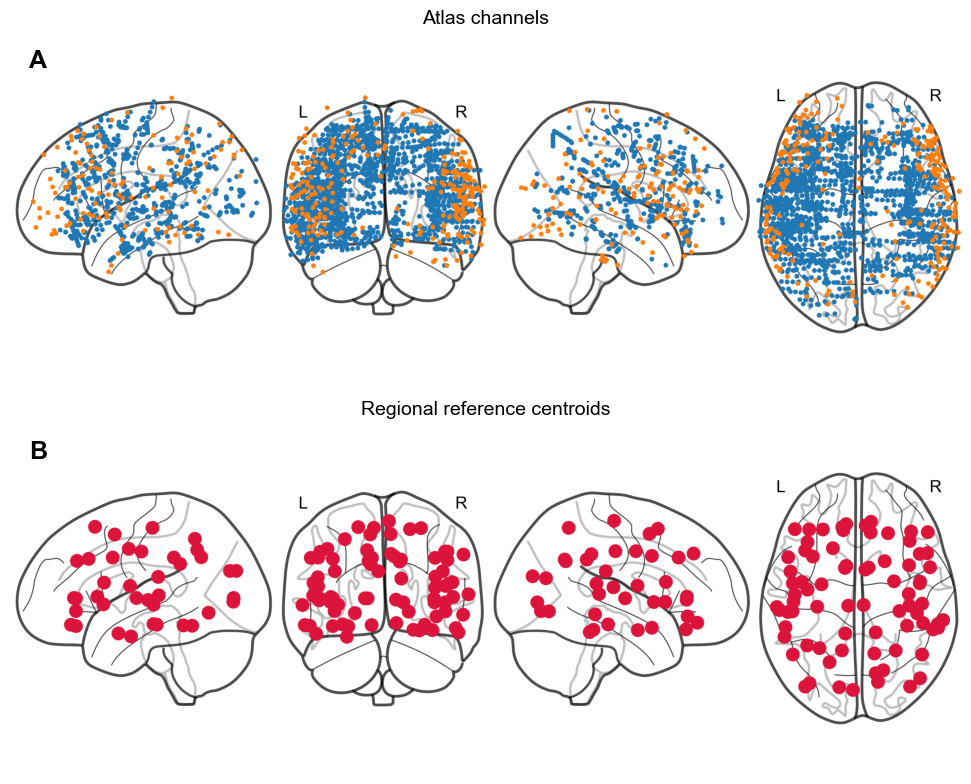

Saved combined PNG to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_and_centroids.png
Saved combined PDF to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_and_centroids.pdf


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from scipy.io import loadmat
from nilearn import plotting

PROJECT_ROOT = Path(PROJECT_ROOT)

channels_csv = PROJECT_ROOT / "data" / "Frauscher2018" / "ChannelInformation.csv"
seeds_mat = PROJECT_ROOT / "data" / "Mantini2018" / "seed_iEEG.mat"
output_dir = Path(f"{PROJECT_ROOT}/notebooks/figures/outputs")

output_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# 1) Channel figure
# ----------------------------
df = pd.read_csv(channels_csv)

for col in ["Electrode type", "Hemisphere"]:
    df[col] = df[col].astype(str).str.strip().str.strip("'").str.upper()

df["x_signed"] = df["x"].abs()
df.loc[df["Hemisphere"] == "L", "x_signed"] *= -1

seeg = df[df["Electrode type"].isin(["D", "M", "A"])]
grid = df[df["Electrode type"] == "G"]

coords_seeg = seeg[["x_signed", "y", "z"]].to_numpy()
coords_grid = grid[["x_signed", "y", "z"]].to_numpy()

display1 = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display1.add_markers(coords_seeg, marker_size=6, marker_color="tab:blue")
display1.add_markers(coords_grid, marker_size=6, marker_color="tab:orange")

channels_png = output_dir / "frauscher_channels.png"
display1.savefig(str(channels_png), dpi=300)
plt.close("all")

# ----------------------------
# 2) Centroid figure
# ----------------------------
mat = loadmat(seeds_mat, squeeze_me=True, struct_as_record=False)
seed_info = np.ravel(mat["seed_info"])

rows = []
for item in seed_info:
    label = str(item.label).strip().strip("'")
    coord = np.asarray(item.coord_mni, dtype=float).ravel()
    rows.append([label, coord[0], coord[1], coord[2]])

centroids = pd.DataFrame(rows, columns=["label", "x", "y", "z"])

display2 = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display2.add_markers(
    centroids[["x", "y", "z"]].to_numpy(),
    marker_size=80,
    marker_color="crimson",
)

centroids_png = output_dir / "frauscher_centroids.png"
display2.savefig(str(centroids_png), dpi=300)
plt.close("all")

# ----------------------------

# 3) Combine saved PNGs

# ----------------------------

img1 = mpimg.imread(channels_png)
img2 = mpimg.imread(centroids_png)
fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor="white")

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("Atlas channels", fontsize=14)
axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("Regional reference centroids", fontsize=14)

# Panel labels

axes[0].text(
    0.02,
    0.95,
    "A",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2),
)

axes[1].text(
    0.02,
    0.95,
    "B",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2),
)

plt.tight_layout()

combined_png = output_dir / "frauscher_channels_and_centroids.png"

combined_pdf = output_dir / "frauscher_channels_and_centroids.pdf"

plt.savefig(combined_png, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(combined_pdf, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved combined PNG to: {combined_png}")
print(f"Saved combined PDF to: {combined_pdf}")

In [ ]:
import pandas as pd
from pathlib import Path
from nilearn import plotting

# Example: a CSV with columns
# label,x,y,z
# Cuneus_l,-3.2986,-82.7236,25.6375
# Cuneus_r,13.2624,-70.7048,20.2776

centroids = pd.read_csv(f"{PROJECT_ROOT}/data/Mantini2018/seed_iEEG.mat")

coords = centroids[["x", "y", "z"]].to_numpy()

output_dir = Path(f"{PROJECT_ROOT}/results")
output_dir.mkdir(parents=True, exist_ok=True)

display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display.add_markers(
    coords,
    marker_size=80,
    marker_color="tab:red",
)

png_path = output_dir / "frauscher_reference_centroids.png"
pdf_path = output_dir / "frauscher_reference_centroids.pdf"

display.savefig(str(png_path), dpi=300)
display.savefig(str(pdf_path))

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

plotting.show()

In [ ]:
import pandas as pd
from pathlib import Path
from nilearn import plotting

# Example: a CSV with columns
# label,x,y,z
# Cuneus_l,-3.2986,-82.7236,25.6375
# Cuneus_r,13.2624,-70.7048,20.2776

centroids = pd.read_csv(f"{PROJECT_ROOT}/data/Frauscher2018/reference_centroids.csv")

coords = centroids[["x", "y", "z"]].to_numpy()

output_dir = Path(f"{PROJECT_ROOT}/results")
output_dir.mkdir(parents=True, exist_ok=True)

display = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
)

display.add_markers(
    coords,
    marker_size=80,
    marker_color="tab:red",
)

png_path = output_dir / "frauscher_reference_centroids.png"
pdf_path = output_dir / "frauscher_reference_centroids.pdf"

display.savefig(str(png_path), dpi=300)
display.savefig(str(pdf_path))

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

plotting.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, surface
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


CSV_PATH = f"{PROJECT_ROOT}/data/Frauscher2018/ChannelInformation.csv"

# Paper-like colors
SEEG_COLOR = "#1f4aa8"   # blue
GRID_COLOR = "#f0d83a"   # yellow
SURF_COLOR = "#b7c3c6"   # light gray-blue


def clean_string_series(s):
    return s.astype(str).str.strip().str.strip("'").str.upper()


def load_frauscher_channels(csv_path):
    df = pd.read_csv(csv_path)

    df["Electrode type"] = clean_string_series(df["Electrode type"])
    df["Hemisphere"] = clean_string_series(df["Hemisphere"])
    df["Channel name"] = df["Channel name"].astype(str).str.strip().str.strip("'")

    df["contact_class"] = np.where(
        df["Electrode type"].eq("G"),
        "grid",
        "seeg",
    )

    df["color"] = np.where(
        df["contact_class"].eq("grid"),
        GRID_COLOR,
        SEEG_COLOR,
    )

    return df


def nearest_surface_vertices(points, surf_vertices):
    """
    Project each point to nearest surface vertex.
    Simple and effective for paper-like visualization.
    """
    # shape: (n_points, n_vertices, 3)
    diffs = points[:, None, :] - surf_vertices[None, :, :]
    dist2 = np.sum(diffs ** 2, axis=2)
    nearest_idx = np.argmin(dist2, axis=1)
    return surf_vertices[nearest_idx]


def subset_by_hemisphere(df, hemi):
    hemi = hemi.upper()
    return df.loc[df["Hemisphere"] == hemi].copy()


def split_points_by_class(df_subset):
    seeg = df_subset.loc[df_subset["contact_class"] == "seeg", ["x", "y", "z"]].to_numpy()
    grid = df_subset.loc[df_subset["contact_class"] == "grid", ["x", "y", "z"]].to_numpy()
    return seeg, grid


def draw_surface(ax, coords, faces, alpha=0.22):
    ax.plot_trisurf(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        triangles=faces,
        color=SURF_COLOR,
        alpha=alpha,
        linewidth=0.0,
        antialiased=True,
        shade=True,
    )


def draw_contacts(ax, seeg_pts, grid_pts, size=12):
    if len(seeg_pts):
        ax.scatter(
            seeg_pts[:, 0], seeg_pts[:, 1], seeg_pts[:, 2],
            s=size, c=SEEG_COLOR, depthshade=False, edgecolors="k", linewidths=0.15
        )
    if len(grid_pts):
        ax.scatter(
            grid_pts[:, 0], grid_pts[:, 1], grid_pts[:, 2],
            s=size, c=GRID_COLOR, depthshade=False, edgecolors="k", linewidths=0.15
        )


def set_equal_3d_axes(ax, vertices):
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    centers = (mins + maxs) / 2.0
    radius = (maxs - mins).max() / 2.0

    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)


def style_ax(ax):
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])


def make_panel(ax, surf_coords, surf_faces, seeg_pts, grid_pts, elev, azim, title, alpha=0.22):
    draw_surface(ax, surf_coords, surf_faces, alpha=alpha)
    draw_contacts(ax, seeg_pts, grid_pts, size=12)
    set_equal_3d_axes(ax, surf_coords)
    style_ax(ax)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=11, pad=6)


def main(CSV_PATH):
    df = load_frauscher_channels(CSV_PATH)

    # Frauscher metadata says x, y, z are MNI coordinates and electrode type codes define contact class.
    # D/M/A = depth or sEEG, G = grid/strip. Hemisphere = L or R.
    # See supplementary info.  [oai_citation:1‡ExtraInformation.txt](sediment://file_00000000e19c720aafd126a1794dcacf)

    fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

    # Load surfaces
    lh_pial_coords, lh_pial_faces = surface.load_surf_mesh(fsavg.pial_left)
    rh_pial_coords, rh_pial_faces = surface.load_surf_mesh(fsavg.pial_right)
    lh_infl_coords, lh_infl_faces = surface.load_surf_mesh(fsavg.infl_left)
    rh_infl_coords, rh_infl_faces = surface.load_surf_mesh(fsavg.infl_right)

    # Split by hemisphere
    df_l = subset_by_hemisphere(df, "L")
    df_r = subset_by_hemisphere(df, "R")

    l_seeg_raw, l_grid_raw = split_points_by_class(df_l)
    r_seeg_raw, r_grid_raw = split_points_by_class(df_r)

    # Top row: use raw coordinates, like pial/lateral view
    # Bottom row: project to inflated surface, matching paper caption more closely
    l_seeg_proj = nearest_surface_vertices(l_seeg_raw, lh_infl_coords) if len(l_seeg_raw) else l_seeg_raw
    l_grid_proj = nearest_surface_vertices(l_grid_raw, lh_infl_coords) if len(l_grid_raw) else l_grid_raw
    r_seeg_proj = nearest_surface_vertices(r_seeg_raw, rh_infl_coords) if len(r_seeg_raw) else r_seeg_raw
    r_grid_proj = nearest_surface_vertices(r_grid_raw, rh_infl_coords) if len(r_grid_raw) else r_grid_raw

    fig = plt.figure(figsize=(12, 10), facecolor="white")

    ax1 = fig.add_subplot(2, 2, 1, projection="3d")
    ax2 = fig.add_subplot(2, 2, 2, projection="3d")
    ax3 = fig.add_subplot(2, 2, 3, projection="3d")
    ax4 = fig.add_subplot(2, 2, 4, projection="3d")

    # Views chosen to resemble the paper qualitatively
    make_panel(
        ax1, lh_pial_coords, lh_pial_faces,
        l_seeg_raw, l_grid_raw,
        elev=12, azim=180,
        title="Left hemisphere"
    )
    make_panel(
        ax2, rh_pial_coords, rh_pial_faces,
        r_seeg_raw, r_grid_raw,
        elev=12, azim=0,
        title="Right hemisphere"
    )
    make_panel(
        ax3, lh_infl_coords, lh_infl_faces,
        l_seeg_proj, l_grid_proj,
        elev=8, azim=180,
        title="Left inflated"
    )
    make_panel(
        ax4, rh_infl_coords, rh_infl_faces,
        r_seeg_proj, r_grid_proj,
        elev=8, azim=0,
        title="Right inflated"
    )

    # Small manual legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker="o", color="w", label="sEEG / depth (D, M, A)",
               markerfacecolor=SEEG_COLOR, markeredgecolor="k", markeredgewidth=0.4, markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Grid / strip (G)",
               markerfacecolor=GRID_COLOR, markeredgecolor="k", markeredgewidth=0.4, markersize=8),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=11)

    plt.subplots_adjust(wspace=0.02, hspace=0.05, bottom=0.08, top=0.95)
    plt.savefig("frauscher_like_4panel.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()




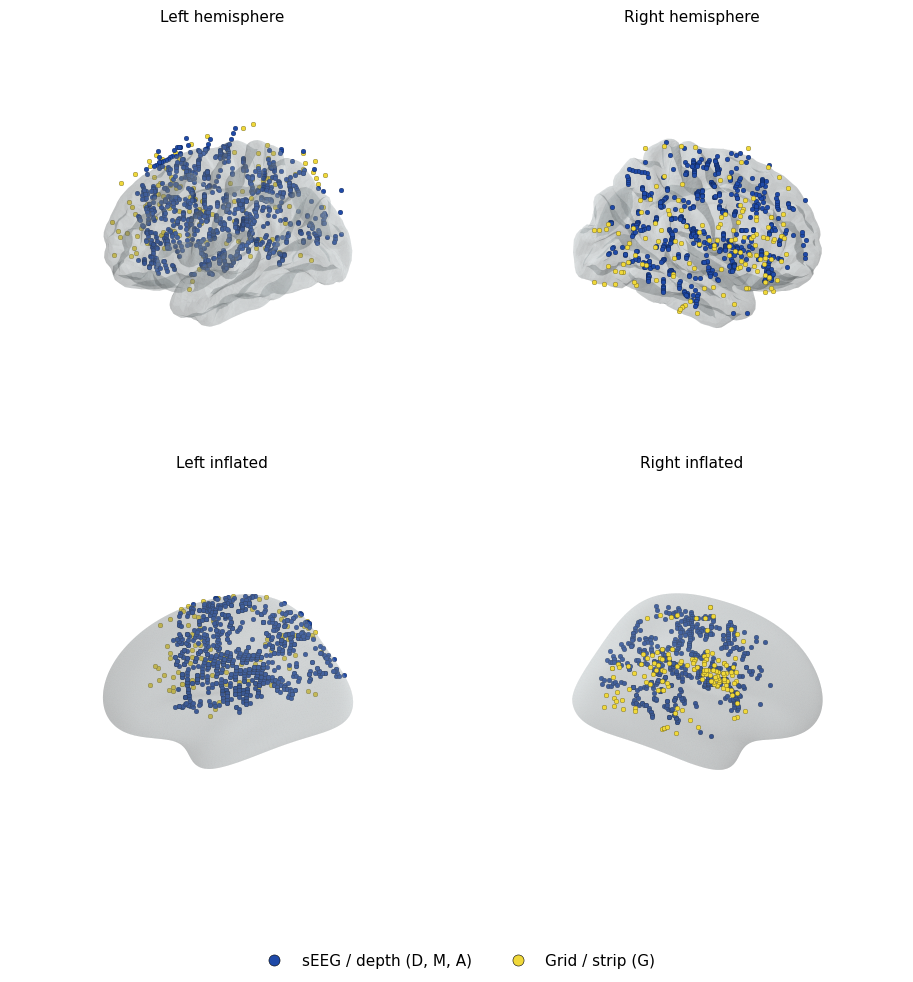

In [5]:
main(CSV_PATH)